In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,classification_report

In [2]:
from catboost import CatBoostClassifier
import shap
import matplotlib.pyplot as plt

C:\Users\ADMIN\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df=pd.read_csv('heart.csv')
target='HeartDisease'

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df['Cholesterol']=df.groupby(target)['Cholesterol'].transform(lambda x:x.replace(0,x.mean()))

In [6]:
df['RestingBP']=df.groupby(target)['RestingBP'].transform(lambda x:x.replace(0,x.mean()))

In [7]:
df=pd.get_dummies(df,drop_first=True)

In [8]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [9]:

df["Cholesterol_ST_Slope_Flat"] = df["Cholesterol"] * df["ST_Slope_Flat"]


df["RestingBP_ST_Slope_Up"] = df["RestingBP"] * df["ST_Slope_Up"]


df["Sex_M_ST_Slope_Flat"] = df["Sex_M"] * df["ST_Slope_Flat"]

df["ChestPainType_ATA_RestingECG_Normal"] = (
    df["ChestPainType_ATA"] * df["RestingECG_Normal"]
)


df["Cholesterol_Sex_M"] = df["Cholesterol"] * df["Sex_M"]


df["Oldpeak_Sex_M"] = df["Oldpeak"] * df["Sex_M"]

df["RestingBP_ST_Slope_Flat"] = df["RestingBP"] * df["ST_Slope_Flat"]

df["Cholesterol_RestingECG_Normal"] = (
    df["Cholesterol"] * df["RestingECG_Normal"]
)


df["Age_Sex_M"] = df["Age"] * df["Sex_M"]


df["RestingBP_MaxHR"] = df["RestingBP"] * df["MaxHR"]

df["Age_MaxHR"] = df["Age"] * df["MaxHR"]

df["ChestPainType_ATA_ST_Slope_Up"] = (
    df["ChestPainType_ATA"] * df["ST_Slope_Up"]
)

df["ChestPainType_NAP_ST_Slope_Up"] = (
    df["ChestPainType_NAP"] * df["ST_Slope_Up"]
)

df["RestingBP_Oldpeak"] = df["RestingBP"] * df["Oldpeak"]

df["RestingBP_Cholesterol"] = df["RestingBP"] * df["Cholesterol"]

df["Oldpeak_ExerciseAngina_Y"] = (
    df["Oldpeak"] * df["ExerciseAngina_Y"]
)

df["Sex_M_ST_Slope_Up"] = df["Sex_M"] * df["ST_Slope_Up"]

df["Sex_M_ST_Slope_Flat"] = df["Sex_M"] * df["ST_Slope_Flat"]

df["Oldpeak_Sex_M"] = df["Oldpeak"] * df["Sex_M"]

df["FastingBS_ST_Slope_Up"] = df["FastingBS"] * df["ST_Slope_Up"]

df["FastingBS_ST_Slope_Flat"] = df["FastingBS"] * df["ST_Slope_Flat"]

In [10]:
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,...,RestingBP_MaxHR,Age_MaxHR,ChestPainType_ATA_ST_Slope_Up,ChestPainType_NAP_ST_Slope_Up,RestingBP_Oldpeak,RestingBP_Cholesterol,Oldpeak_ExerciseAngina_Y,Sex_M_ST_Slope_Up,FastingBS_ST_Slope_Up,FastingBS_ST_Slope_Flat
0,40,140.0,289.0,0,172,0.0,0,True,True,False,...,24080.0,6880,True,False,0.0,40460.0,0.0,True,0,0
1,49,160.0,180.0,0,156,1.0,1,False,False,True,...,24960.0,7644,False,False,160.0,28800.0,0.0,False,0,0
2,37,130.0,283.0,0,98,0.0,0,True,True,False,...,12740.0,3626,True,False,0.0,36790.0,0.0,True,0,0
3,48,138.0,214.0,0,108,1.5,1,False,False,False,...,14904.0,5184,False,False,207.0,29532.0,1.5,False,0,0
4,54,150.0,195.0,0,122,0.0,0,True,False,True,...,18300.0,6588,False,True,0.0,29250.0,0.0,True,0,0


In [11]:
x=df.drop(target,axis=1)
y=df[target]
feature_names=x.columns

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [13]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [14]:
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train_scaled,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [15]:
explainer=shap.TreeExplainer(gb)
shap_values=explainer.shap_values(x_train_scaled)
importance=np.abs(shap_values).mean(axis=0)
selected_mask=importance >= 0.1
selected_features=feature_names[selected_mask]
print("Selected features")
for f in selected_features:
    print(f)

Selected features
Cholesterol
MaxHR
Oldpeak
ChestPainType_NAP
ExerciseAngina_Y
Cholesterol_ST_Slope_Flat
RestingBP_ST_Slope_Up
ChestPainType_ATA_RestingECG_Normal
Cholesterol_Sex_M
Oldpeak_Sex_M
RestingBP_ST_Slope_Flat
Cholesterol_RestingECG_Normal
RestingBP_MaxHR
Age_MaxHR
ChestPainType_ATA_ST_Slope_Up
RestingBP_Oldpeak
RestingBP_Cholesterol
Oldpeak_ExerciseAngina_Y


In [16]:
x_train_sel=x_train_scaled[:,selected_mask]
x_test_sel=x_test_scaled[:,selected_mask]

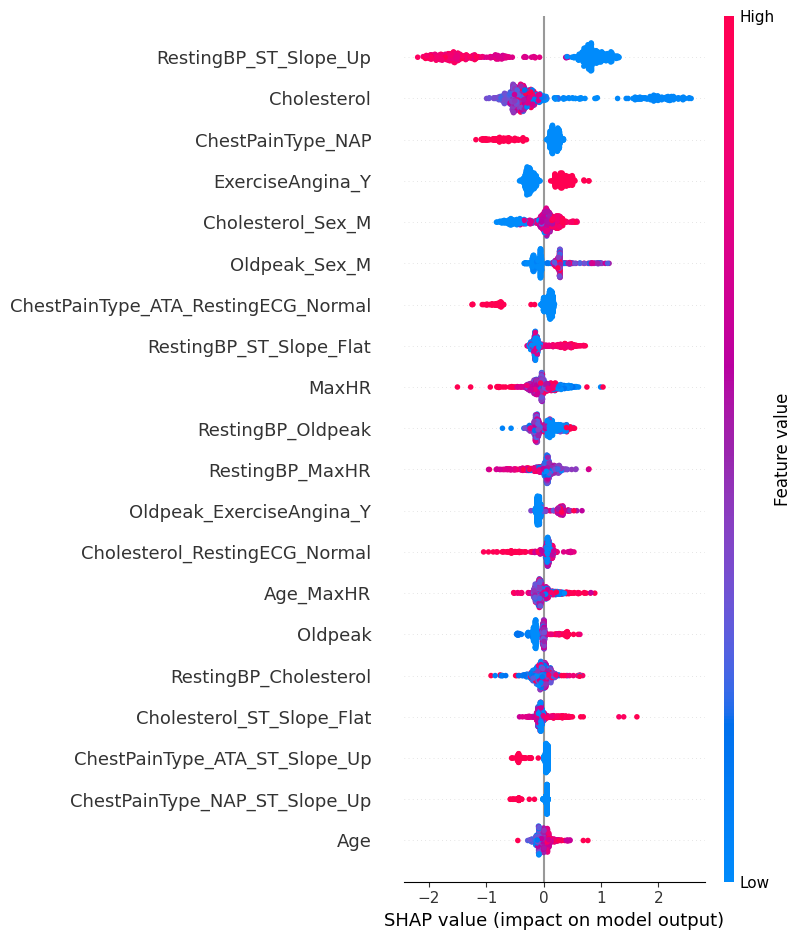

In [17]:
shap.summary_plot(shap_values,x_train_scaled,feature_names=feature_names)

In [18]:
from sklearn.model_selection import GridSearchCV
scoring='f1'
cv=5

In [21]:
#XGBoost
from xgboost import XGBClassifier
xgb=XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss')
param_grid={
    'n_estimators':[100,200],
    'max_depth':[3,5],
    'learning_rate':[0.01,0.1],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1]
}
grid_xgb=GridSearchCV(xgb,param_grid,scoring=scoring,cv=cv,n_jobs=-1)
grid_xgb.fit(x_train_sel,y_train)
print("Best Params:",
      grid_xgb.best_params_)

Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


Accuracy: 0.9021739130434783
Precision: 0.9090909090909091
Recall: 0.9150326797385621
F1 Score: 0.9120521172638436
ROC AUC: 0.9525479568521176
Confusion_matrix


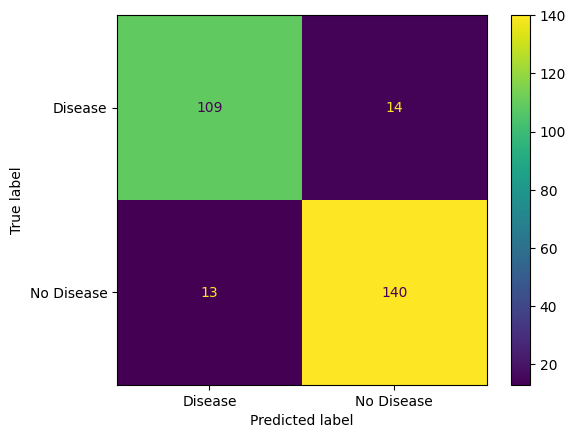

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

xgb_final = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_final.fit(x_train_sel, y_train)
y_pred = xgb_final.predict(x_test_sel)
y_prob = xgb_final.predict_proba(x_test_sel)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
cm=confusion_matrix(y_test,y_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()

In [26]:
#adaboost
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

grid_ada = GridSearchCV(ada, param_grid, scoring=scoring, cv=cv, n_jobs=-1)
grid_ada.fit(x_train_sel, y_train)

print("Best Params:", grid_ada.best_params_)

Best Params: {'learning_rate': 1, 'n_estimators': 100}


Accuracy: 0.8876811594202898
Precision: 0.9066666666666666
Recall: 0.8888888888888888
F1 Score: 0.8976897689768977
ROC AUC: 0.8875338753387534
Confusion_matrix


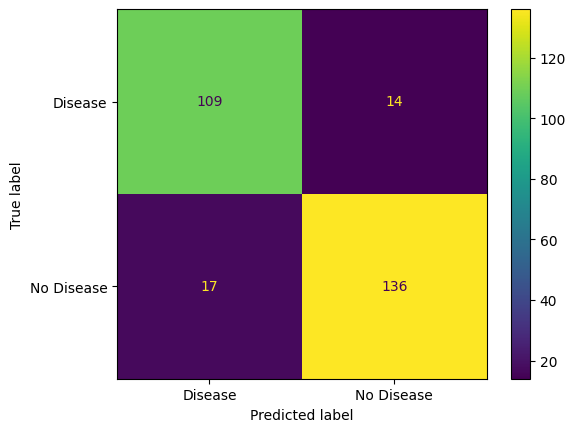

In [31]:

ada_final=AdaBoostClassifier(
    learning_rate=1,
    n_estimators=100,
    random_state=42
)
ada_final.fit(x_train_sel,y_train)
ada_pred=ada_final.predict(x_test_sel)

print("Accuracy:", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred))
print("Recall:", recall_score(y_test, ada_pred))
print("F1 Score:", f1_score(y_test, ada_pred))
print("ROC AUC:", roc_auc_score(y_test, ada_pred))
cm=confusion_matrix(y_test,ada_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()

In [32]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [-1, 5, 10],
    'num_leaves': [31, 50]
}

grid_lgb = GridSearchCV(lgb, param_grid, scoring=scoring, cv=cv, n_jobs=-1)
grid_lgb.fit(x_train_sel, y_train)

print("Best Params:", grid_lgb.best_params_)

[LightGBM] [Info] Number of positive: 355, number of negative: 287
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.552960 -> initscore=0.212636
[LightGBM] [Info] Start training from score 0.212636
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Info] Number of positive: 355, number of negative: 287
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001123 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1394
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.552960 -> initscore=0.212636
[LightGBM] [Info] Start training from score 0.212636
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

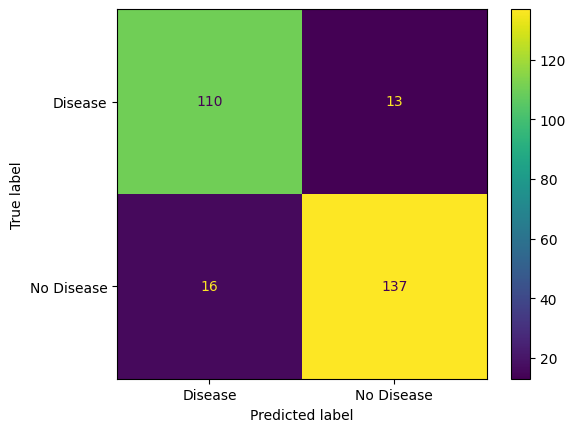

In [33]:
light_final=LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31
)
light_final.fit(x_train_sel,y_train)
lgbm_pred=light_final.predict(x_test_sel)
print("Accuracy:", accuracy_score(y_test, lgbm_pred))
print("Precision:", precision_score(y_test, lgbm_pred))
print("Recall:", recall_score(y_test, lgbm_pred))
print("F1 Score:", f1_score(y_test, lgbm_pred))
print("ROC AUC:", roc_auc_score(y_test, lgbm_pred))
cm=confusion_matrix(y_test,lgbm_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()

In [34]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid_extra = GridSearchCV(extra, param_grid, scoring=scoring, cv=cv, n_jobs=-1)
grid_extra.fit(x_train_sel, y_train)

print("Best Params:", grid_extra.best_params_)

Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


Accuracy: 0.8442028985507246
Precision: 0.8481012658227848
Recall: 0.8758169934640523
F1 Score: 0.8617363344051447
ROC AUC: 0.8403475211222702
Confusion_matrix


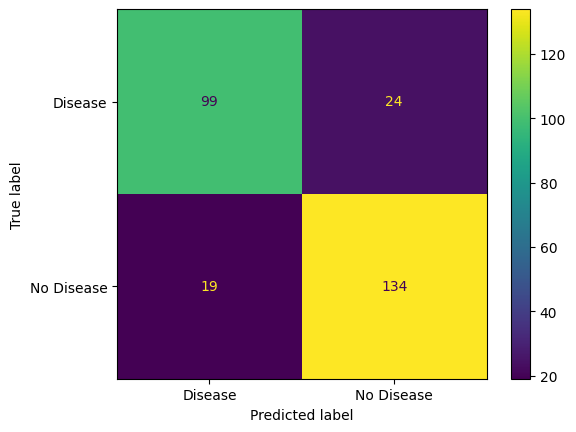

In [35]:
extra_final=ExtraTreesClassifier(
    max_depth=10,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
extra_final.fit(x_train_sel,y_train)
e_pred=extra_final.predict(x_test_sel)
print("Accuracy:", accuracy_score(y_test, e_pred))
print("Precision:", precision_score(y_test, e_pred))
print("Recall:", recall_score(y_test, e_pred))
print("F1 Score:", f1_score(y_test, e_pred))
print("ROC AUC:", roc_auc_score(y_test, e_pred))
cm=confusion_matrix(y_test,e_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

grid_rf = GridSearchCV(rf, param_grid, scoring=scoring, cv=cv, n_jobs=-1)
grid_rf.fit(x_train_sel, y_train)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


Accuracy: 0.8840579710144928
Precision: 0.8757763975155279
Recall: 0.9215686274509803
F1 Score: 0.8980891719745223
ROC AUC: 0.87948350071736
Confusion_matrix


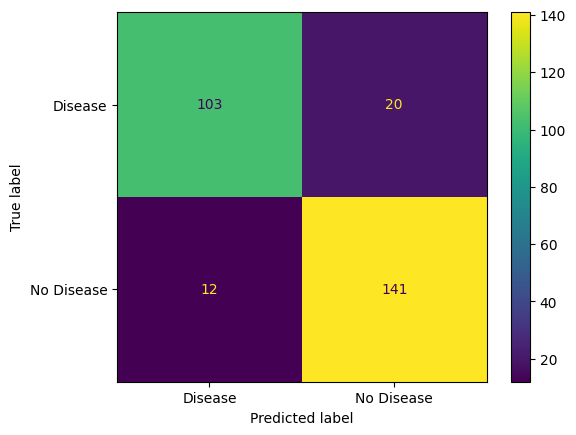

In [37]:
rf_final=RandomForestClassifier(
    random_state=42,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=2,
    n_estimators=100
)
rf_final.fit(x_train_sel,y_train)
rf_pred=rf_final.predict(x_test_sel)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_pred))
cm=confusion_matrix(y_test,rf_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()

In [40]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)
param_grid = {
    'iterations': [300, 500],
    'depth': [5, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5, 7],
    'bagging_temperature': [0, 1],
    'border_count': [64, 128]
}
grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='f1',   
    cv=5,
    n_jobs=-1
)
grid_cat.fit(x_train_sel, y_train)

print("Best Params:", grid_cat.best_params_)

Best Params: {'bagging_temperature': 0, 'border_count': 128, 'depth': 5, 'iterations': 300, 'l2_leaf_reg': 7, 'learning_rate': 0.03}


0:	learn: 0.6727488	total: 7.98ms	remaining: 2.39s
1:	learn: 0.6534925	total: 13.8ms	remaining: 2.05s
2:	learn: 0.6356189	total: 20ms	remaining: 1.98s
3:	learn: 0.6181278	total: 26.8ms	remaining: 1.98s
4:	learn: 0.6013841	total: 33.4ms	remaining: 1.97s
5:	learn: 0.5832048	total: 39.6ms	remaining: 1.94s
6:	learn: 0.5690244	total: 45.9ms	remaining: 1.92s
7:	learn: 0.5551859	total: 52.4ms	remaining: 1.91s
8:	learn: 0.5428105	total: 59.9ms	remaining: 1.94s
9:	learn: 0.5308522	total: 66.7ms	remaining: 1.94s
10:	learn: 0.5194394	total: 72.6ms	remaining: 1.91s
11:	learn: 0.5092977	total: 78.9ms	remaining: 1.89s
12:	learn: 0.4995851	total: 85.3ms	remaining: 1.88s
13:	learn: 0.4908710	total: 91.8ms	remaining: 1.88s
14:	learn: 0.4823394	total: 97.8ms	remaining: 1.86s
15:	learn: 0.4755832	total: 104ms	remaining: 1.84s
16:	learn: 0.4677017	total: 109ms	remaining: 1.82s
17:	learn: 0.4606197	total: 114ms	remaining: 1.79s
18:	learn: 0.4537450	total: 120ms	remaining: 1.77s
19:	learn: 0.4456811	total: 

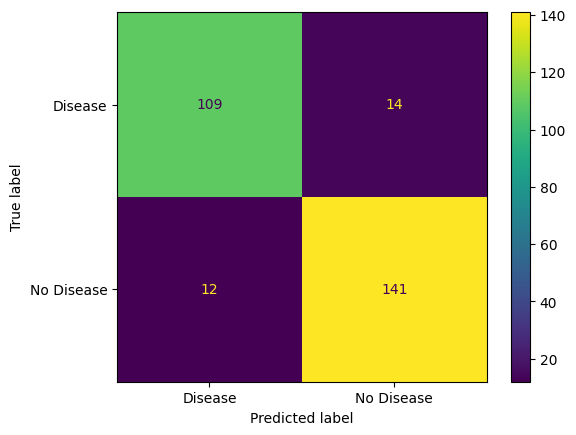

In [42]:
cat_final=CatBoostClassifier(
    random_state=42,
    iterations=300,
    l2_leaf_reg=7,
    bagging_temperature=0,
    border_count=128,
    depth=5,
    learning_rate=0.03)
cat_final.fit(x_train_sel,y_train)
cat_pred=cat_final.predict(x_test_sel)
print("Accuracy:", accuracy_score(y_test, cat_pred))
print("Precision:", precision_score(y_test, cat_pred))
print("Recall:", recall_score(y_test, cat_pred))
print("F1 Score:", f1_score(y_test, cat_pred))
print("ROC AUC:", roc_auc_score(y_test, cat_pred))
cm=confusion_matrix(y_test,cat_pred)
print("Confusion_matrix")
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Disease','No Disease'])
disp.plot()